# EMS training with separate evaluation environments

This notebook keeps training disabled by default. Set `TRAIN = True` only when the configuration has been checked.

In [2]:
import sys
import torch

print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("Compiled CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: c:\Users\Álvaro\Documents\GitHub\RL_EMS\.venv\Scripts\python.exe
Torch: 2.14.1+cu126
Compiled CUDA: 12.6
CUDA available: True
GPU: NVIDIA GeForce RTX 4060


In [4]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
from stable_baselines3 import PPO, SAC, TD3
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.noise import OrnsteinUhlenbeckActionNoise

from environments.EMS_env import EvalMG, MicrogridEnv, NormalisedMG

TRAIN = True
N_ENVS = 8
DAYS_PER_EPISODE = 3
DAY_STEPS = 144
EPISODE_LENGTH = DAY_STEPS * DAYS_PER_EPISODE
TOTAL_TIMESTEPS = 1_600_000
DEVICE = "cuda"

OUTPUT_ROOT = Path("experimental_logs/ems")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

ACTION_NOISE = OrnsteinUhlenbeckActionNoise(
    mean=np.zeros(2),
    sigma=0.1 * np.ones(2),
)

SET_OF_WEIGHTS = np.array([
    [1.0, 4.0, 1.0],
    [1.0, 3.0, 1.0],
    [1.0, 2.0, 1.0],
    [1.0, 1.0, 1.0],
    [1.0, 1.0, 2.0],
    [1.0, 1.0, 3.0],
    [1.0, 1.0, 4.0],
    [1.0, 2.0, 2.0],
    [1.0, 4.0, 4.0],
])

In [5]:
def create_training_env(weights):
    return NormalisedMG(MicrogridEnv(
        weights=np.asarray(weights, dtype=float),
        days_per_episode=DAYS_PER_EPISODE,
        mode="train",
    ))


def create_eval_env(weights, log_file=None):
    env = NormalisedMG(MicrogridEnv(
        weights=np.asarray(weights, dtype=float),
        days_per_episode=DAYS_PER_EPISODE,
        mode="eval",
    ))
    env = EvalMG(env)
    if log_file is not None:
        Path(log_file).parent.mkdir(parents=True, exist_ok=True)
        env = Monitor(env, str(log_file))
    return env


def make_algorithm_env(weights, algorithm, weight_index):
    monitor_dir = OUTPUT_ROOT / f"weights_{weight_index}" / algorithm / "train"
    monitor_dir.mkdir(parents=True, exist_ok=True)
    return make_vec_env(
        lambda: create_training_env(weights),
        n_envs=N_ENVS,
        seed=0,
        monitor_dir=str(monitor_dir),
    )


def create_callback(algorithm, weights, weight_index):
    algorithm_dir = OUTPUT_ROOT / f"weights_{weight_index}" / algorithm
    algorithm_dir.mkdir(parents=True, exist_ok=True)
    eval_env = create_eval_env(
        weights,
        log_file=algorithm_dir / "eval_monitor.csv",
    )
    target_steps = 4 * EPISODE_LENGTH * 16
    eval_freq = max(1, target_steps // N_ENVS)
    callback = EvalCallback(
        eval_env,
        best_model_save_path=str(algorithm_dir),
        log_path=str(algorithm_dir),
        eval_freq=eval_freq,
        deterministic=True,
        render=False,
    )
    return callback, eval_env

In [6]:
def train_one_algorithm(algorithm, weights, weight_index):
    train_env = make_algorithm_env(weights, algorithm, weight_index)
    callback, eval_env = create_callback(algorithm, weights, weight_index)

    try:
        if algorithm == "sac":
            model = SAC(
                "MlpPolicy",
                train_env,
                verbose=1,
                train_freq=10,
                batch_size=512,
                device=DEVICE,
            )
        elif algorithm == "td3":
            model = TD3(
                "MlpPolicy",
                train_env,
                action_noise=ACTION_NOISE,
                verbose=1,
                train_freq=10,
                batch_size=512,
                target_policy_noise=0.1,
                device=DEVICE,
            )
        elif algorithm == "ppo":
            model = PPO(
                "MlpPolicy",
                train_env,
                batch_size=EPISODE_LENGTH * N_ENVS,
                n_steps=EPISODE_LENGTH * 2,
                n_epochs=12,
                learning_rate=3e-4,
                ent_coef=0.1,
                clip_range=0.12,
                verbose=1,
                device=DEVICE,
            )
        else:
            raise ValueError(f"Unknown algorithm: {algorithm}")

        started = time.time()
        model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback)
        print(f"Training {algorithm} took {time.time() - started:.1f} seconds")
    finally:
        eval_env.close()
        train_env.close()


def train_all():
    for weight_index, weights in enumerate(SET_OF_WEIGHTS):
        print(f"Training with weights {weights}")
        for algorithm in ("sac", "td3", "ppo"):
            train_one_algorithm(algorithm, weights, weight_index)


if TRAIN:
    train_all()
else:
    print("TRAIN is False; no training was started.")

Training with weights [1. 4. 1.]
Using cuda device
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 432       |
|    ep_rew_mean     | -1.19e+03 |
| time/              |           |
|    episodes        | 4         |
|    fps             | 1537      |
|    time_elapsed    | 2         |
|    total_timesteps | 3456      |
| train/             |           |
|    actor_loss      | 0.346     |
|    critic_loss     | 3.71      |
|    ent_coef        | 0.988     |
|    ent_coef_loss   | -0.0415   |
|    learning_rate   | 0.0003    |
|    n_updates       | 42        |
----------------------------------
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 432       |
|    ep_rew_mean     | -1.19e+03 |
| time/              |           |
|    episodes        | 8         |
|    fps             | 1536      |
|    time_elapsed    | 2         |
|    total_timesteps | 3456      |
----------------------------------
----

c:\Users\Álvaro\Documents\GitHub\RL_EMS\.venv\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 432      |
|    ep_rew_mean     | -629     |
| time/              |          |
|    fps             | 3049     |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 6912     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 432          |
|    ep_rew_mean          | -597         |
| time/                   |              |
|    fps                  | 2740         |
|    iterations           | 2            |
|    time_elapsed         | 5            |
|    total_timesteps      | 13824        |
| train/                  |              |
|    approx_kl            | 0.0031999003 |
|    clip_fraction        | 0.0855       |
|    clip_range           | 0.12         |
|    entropy_loss         | -2.84        |
|    explained_variance   | 0.0145       |
|    learning_r

c:\Users\Álvaro\Documents\GitHub\RL_EMS\.venv\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 432      |
|    ep_rew_mean     | -518     |
| time/              |          |
|    fps             | 2558     |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 6912     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 432          |
|    ep_rew_mean          | -530         |
| time/                   |              |
|    fps                  | 2594         |
|    iterations           | 2            |
|    time_elapsed         | 5            |
|    total_timesteps      | 13824        |
| train/                  |              |
|    approx_kl            | 0.0035668486 |
|    clip_fraction        | 0.0873       |
|    clip_range           | 0.12         |
|    entropy_loss         | -2.84        |
|    explained_variance   | 0.00208      |
|    learning_r

...

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 432      |
|    ep_rew_mean     | -179     |
| time/              |          |
|    fps             | 3016     |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 6912     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 432          |
|    ep_rew_mean          | -210         |
| time/                   |              |
|    fps                  | 2983         |
|    iterations           | 2            |
|    time_elapsed         | 4            |
|    total_timesteps      | 13824        |
| train/                  |              |
|    approx_kl            | 0.0012555696 |
|    clip_fraction        | 0.0346       |
|    clip_range           | 0.12         |
|    entropy_loss         | -2.84        |
|    explained_variance   | 0.0227       |
|    learning_r

c:\Users\Álvaro\Documents\GitHub\RL_EMS\.venv\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 432      |
|    ep_rew_mean     | -348     |
| time/              |          |
|    fps             | 3037     |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 6912     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 432          |
|    ep_rew_mean          | -321         |
| time/                   |              |
|    fps                  | 2976         |
|    iterations           | 2            |
|    time_elapsed         | 4            |
|    total_timesteps      | 13824        |
| train/                  |              |
|    approx_kl            | 0.0020582527 |
|    clip_fraction        | 0.0568       |
|    clip_range           | 0.12         |
|    entropy_loss         | -2.84        |
|    explained_variance   | -0.00158     |
|    learning_r

c:\Users\Álvaro\Documents\GitHub\RL_EMS\.venv\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 432      |
|    ep_rew_mean     | -635     |
| time/              |          |
|    fps             | 3051     |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 6912     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 432          |
|    ep_rew_mean          | -635         |
| time/                   |              |
|    fps                  | 3026         |
|    iterations           | 2            |
|    time_elapsed         | 4            |
|    total_timesteps      | 13824        |
| train/                  |              |
|    approx_kl            | 0.0033150597 |
|    clip_fraction        | 0.0813       |
|    clip_range           | 0.12         |
|    entropy_loss         | -2.84        |
|    explained_variance   | 0.00479      |
|    learning_r

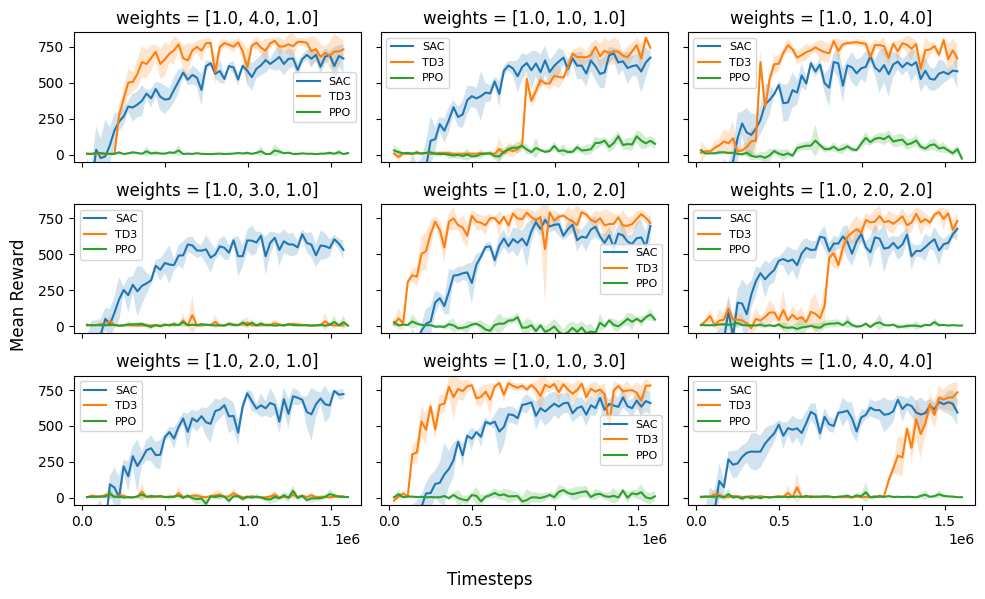

Saved experimental_logs\ems\training_curves.png


In [7]:
def plot_training_curves():
    fig, axes = plt.subplots(3, 3, figsize=(10, 6), sharex="col", sharey="row")

    for weight_index, weights in enumerate(SET_OF_WEIGHTS):
        axis = axes[weight_index % 3, weight_index // 3]
        for algorithm in ("sac", "td3", "ppo"):
            result_file = OUTPUT_ROOT / f"weights_{weight_index}" / algorithm / "evaluations.npz"
            if not result_file.exists():
                continue
            data = np.load(result_file)
            scores = data["results"].mean(axis=1)
            deviations = data["results"].std(axis=1)
            timesteps = data["timesteps"]
            axis.plot(timesteps, scores, label=algorithm.upper())
            axis.fill_between(timesteps, scores - deviations, scores + deviations, alpha=0.2)

        axis.set_title(f"weights = {weights.tolist()}")
        axis.set_ylim(-50, 850)
        axis.legend(fontsize=8)

    fig.supxlabel("Timesteps")
    fig.supylabel("Mean Reward")
    fig.tight_layout()
    output_file = OUTPUT_ROOT / "training_curves.png"
    fig.savefig(output_file, dpi=300)
    plt.show()
    print(f"Saved {output_file}")


plot_training_curves()